In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
#Data 
test_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')

included_cols = list(train_transaction.columns)
print('List columns: ' + str(included_cols) )
 
print('Test transactions shape: ' + str(test_transaction.shape) + ', identity ' + str(test_identity.shape) )
print('Train transactions shape: ' + str(train_transaction.shape) + ', identity ' + str(train_identity.shape) )
print('Train transactions preview:')
train_transaction.head(5)


In [ ]:

train_transaction['TransactionDay'] = train_transaction['TransactionDT'] / 86400
test_transaction['TransactionDay'] = test_transaction['TransactionDT'] / 86400

test_transaction['TransactionDay'].plot(kind='hist', figsize=(15,5), label='test', 
                         bins=200, title='Train and Test TransactionDT Distribution')
train_transaction['TransactionDay'].plot(kind='hist',label='train',bins=200)
plt.legend()
plt.show()

bins = [0,50,100,150,200,250,300,350,400,float('inf')]
labels = ['50','100','150','200','250','300','350','400','450+']

train_transaction['DayGroup'] = pd.cut(
    train_transaction['TransactionDay'],
    bins=bins,
    labels=labels,
    right=False
)

test_transaction['DayGroup'] = pd.cut(
    test_transaction['TransactionDay'],
    bins=bins,
    labels=labels,
    right=False
)
train_count = train_transaction['DayGroup'].value_counts().sort_index()

test_count = test_transaction['DayGroup'].value_counts().sort_index()

summary = pd.DataFrame({
    'Train': train_count,
    'Test': test_count
})

summary.T

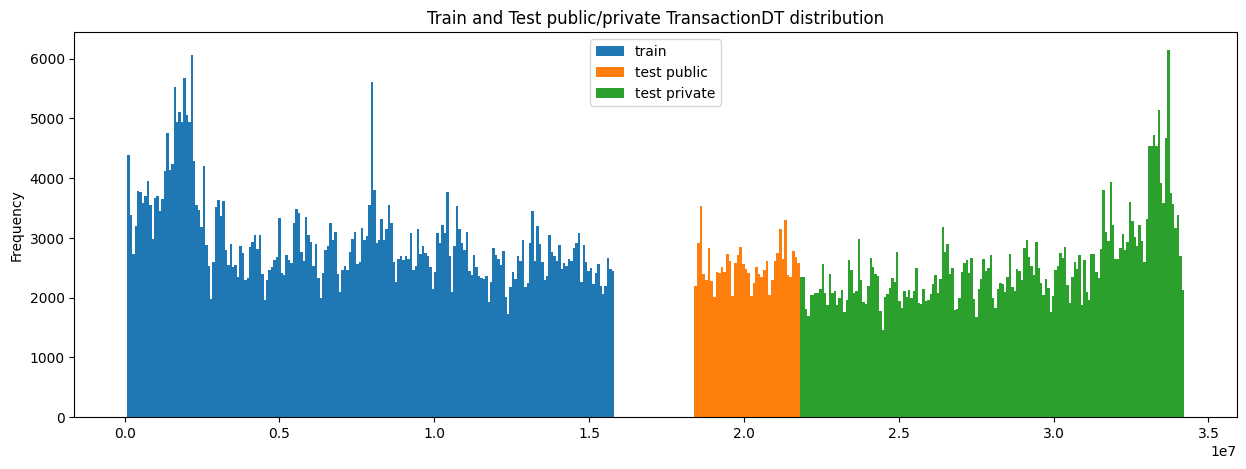

In [31]:
train_transaction['TransactionDT'].plot(kind='hist', figsize=(15, 5), label='train', 
                         bins=200, title='Train and Test public/private TransactionDT distribution')
n_public = int(test_transaction.shape[0] * 0.2) #20% of the test data is public
test_transaction.loc[:n_public, 'TransactionDT'].plot(kind='hist', label='test public', bins=40)
test_transaction.loc[n_public:, 'TransactionDT'].plot(kind='hist', label='test private', bins=160)
plt.legend()
plt.show()